In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('student_performance_dataset.csv')

In [3]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [5]:
df = df.drop(['Student_ID','Pass_Fail','Gender'],axis=1)

In [6]:
from sklearn.preprocessing import LabelEncoder

Label = LabelEncoder()
df['Parental_Education_Level'] = Label.fit_transform(df['Parental_Education_Level'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Study_Hours_per_Week        708 non-null    int64  
 1   Attendance_Rate             708 non-null    float64
 2   Past_Exam_Scores            708 non-null    int64  
 3   Parental_Education_Level    708 non-null    int64  
 4   Internet_Access_at_Home     708 non-null    object 
 5   Extracurricular_Activities  708 non-null    object 
 6   Final_Exam_Score            708 non-null    int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 38.8+ KB


In [7]:
cateorical = df.select_dtypes(include='O').columns

In [8]:
encode_df = pd.get_dummies(df, columns=cateorical, dtype=int, drop_first=True)

In [9]:
encode_df.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Final_Exam_Score,Internet_Access_at_Home_Yes,Extracurricular_Activities_Yes
0,31,68.267841,86,1,63,1,1
1,16,78.222927,73,3,50,0,0
2,21,87.525096,74,3,55,1,0
3,27,92.076483,99,0,65,0,0
4,37,98.655517,63,2,70,0,1


In [10]:
encode_df = encode_df[['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores',
       'Parental_Education_Level',
       'Internet_Access_at_Home_Yes', 'Extracurricular_Activities_Yes','Final_Exam_Score']]
encode_df.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home_Yes,Extracurricular_Activities_Yes,Final_Exam_Score
0,31,68.267841,86,1,1,1,63
1,16,78.222927,73,3,0,0,50
2,21,87.525096,74,3,1,0,55
3,27,92.076483,99,0,0,0,65
4,37,98.655517,63,2,0,1,70


In [21]:
encode_df.columns

Index(['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores',
       'Parental_Education_Level', 'Extracurricular_Activities_Yes',
       'Final_Exam_Score'],
      dtype='object')

In [ ]:
# for better understand  first arrange the columns
encode_df = encode_df[['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores',
       'Parental_Education_Level', 'Extracurricular_Activities_Yes',
       'Final_Exam_Score']]

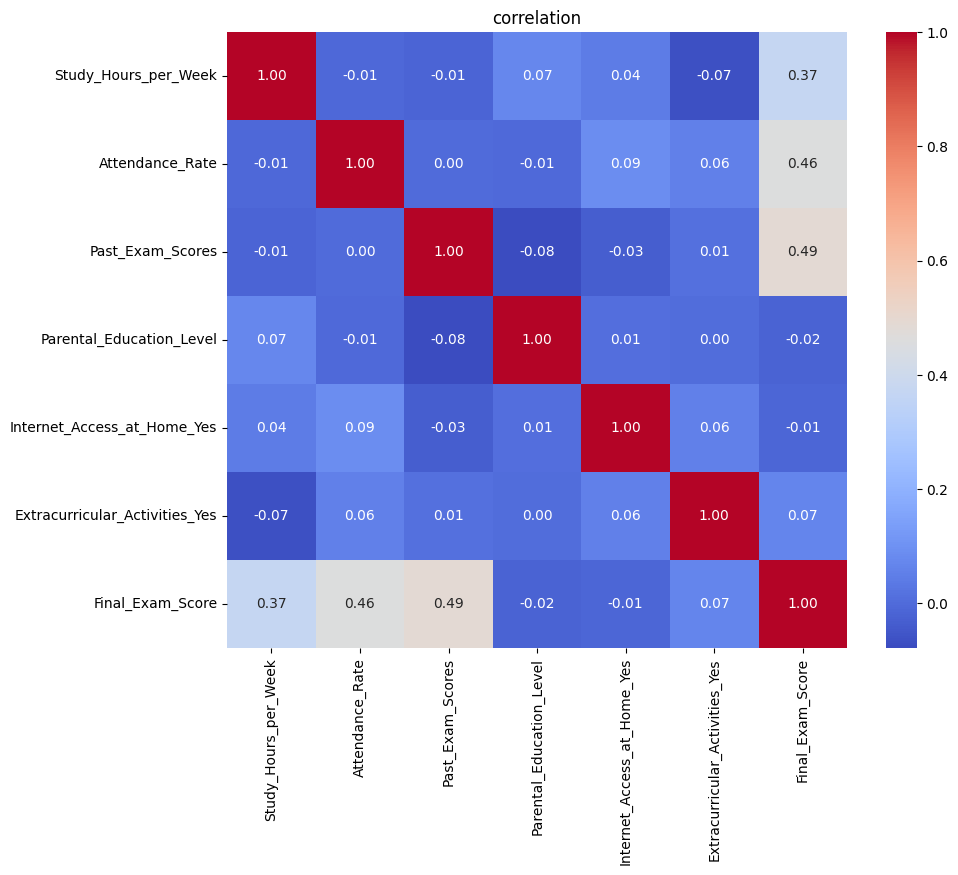

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(encode_df.corr(numeric_only=True),annot=True, cmap='coolwarm', fmt='.2f')
plt.title('correlation')
plt.show()


In [12]:
encode_df = encode_df.drop(['Internet_Access_at_Home_Yes'],axis=1) 

In [13]:
encode_df.head()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Extracurricular_Activities_Yes,Final_Exam_Score
0,31,68.267841,86,1,1,63
1,16,78.222927,73,3,0,50
2,21,87.525096,74,3,0,55
3,27,92.076483,99,0,0,65
4,37,98.655517,63,2,1,70


In [14]:
X = encode_df.drop('Final_Exam_Score',axis=1)
y = encode_df['Final_Exam_Score']

In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Study_Hours_per_Week            708 non-null    int64  
 1   Attendance_Rate                 708 non-null    float64
 2   Past_Exam_Scores                708 non-null    int64  
 3   Parental_Education_Level        708 non-null    int64  
 4   Extracurricular_Activities_Yes  708 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 27.8 KB


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scale, y_train)
y_pred = lr.predict(X_test_scale)

y_pred_train = lr.predict(X_train_scale)
print('mse',mean_squared_error(y_train, y_pred_train))
print('r2',r2_score(y_train, y_pred_train))
print('-'*10)
print('mse',mean_squared_error(y_test, y_pred))
print('r2',r2_score(y_test, y_pred))

mse 18.90610883894144
r2 0.584200629106306
----------
mse 14.225150584362837
r2 0.6656444497485161


In [19]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

lasso = Lasso(alpha=1)
lasso.fit(X_train_scale, y_train)
y_pred = lasso.predict(X_test_scale)

y_pred_train = lasso.predict(X_train_scale)
print('mse',mean_squared_error(y_train, y_pred_train))
print('r2',r2_score(y_train, y_pred_train))
print('-'*10)
print('mse',mean_squared_error(y_test, y_pred))
print('r2',r2_score(y_test, y_pred))

mse 22.154653951629854
r2 0.5127558370720263
----------
mse 18.506211988388706
r2 0.5650200920016857


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor()
param_grid = [{
    'n_estimators':[101,201,151],
    'max_depth':[2,3,4,6],
    'min_samples_split':[4,6,8,20]
}]
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5,scoring='neg_mean_squared_error')
grid.fit(X_train_scale, y_train)
y_pred = grid.predict(X_test_scale)

print('mse',mean_squared_error(y_test, y_pred))
print('r2',r2_score(y_test, y_pred))


mse 11.193562757372353
r2 0.7369005120318459


In [19]:
# mse 14.411983738912244
# r2 0.6612530233221936